In [1]:
import numpy as np
import scipy as sp
from typing import Callable, Union
import pandas as pd
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import os
import pickle
import logging
import time
import sys
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
lgcg_path = os.path.abspath(os.path.join('../nlgcg'))
if lgcg_path not in sys.path:
    sys.path.append(lgcg_path)
from lib.measure import Measure
from lib.ssn import SSN
from lib.particle_descent import ParticleDescent
from nlgcg import NLGCG

# Heat Equation

## Generate Data and Define Functions

In [ ]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [ ]:
# Omega = np.array([[0,1], [0,1]])
# alpha = 1e-1
# observation_resolution = 4
# std_factor = 0.1
# true_sources = np.array([[0.28, 0.71], [0.51,0.27], [0.71,0.53]])
# true_weights = np.array([1,-0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)

In [ ]:
Omega = np.array([[0,1], [0,1]])
alpha = 2e-1
observation_resolution = 10
std_factor = 0.02
np.random.seed(49)
true_sources = np.random.rand(20, 2)*0.9
true_weights = np.random.rand(20) * 2 - 1
true_measure = Measure(support=true_sources, coefficients=true_weights)

In [ ]:
observations = (np.array(np.meshgrid(
                    *(
                        np.linspace(bound[0], bound[1], observation_resolution+2)
                        for bound in Omega
                    ))
            ).reshape(len(Omega), -1).T)
observations = np.array([obs for obs in observations if all(obs!=0) and all(obs!=1)])

In [ ]:
@jax.jit
def kernel(omega: np.ndarray):
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    norms = -jnp.square(jnp.linalg.norm(omega-observations, axis=1))/std_factor # (len(x),)
    exponentiated = jnp.exp(norms)/outer_factor # (len(x),)
    return exponentiated

grad_kernel = jax.jit(jax.jacobian(kernel))
hess_kernel = jax.jit(jax.hessian(kernel))
_ = grad_kernel(true_sources[0])
_ = hess_kernel(true_sources[0])

kernel = jax.vmap(kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [ ]:
target = true_measure.duality_pairing(kernel)

@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
# grad_g = jax.jit(jax.grad(g))
# _ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
f_grad = jax.jit(jax.grad(f))
_ = f_grad(jnp.zeros(target.shape[0]))

j = lambda u: f(u.duality_pairing(kernel)) + g(u.coefficients)

In [ ]:
def p(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: kernel(omega) @ inner

def grad_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

def hess_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [ ]:
@jax.jit
def j_N(input: np.ndarray):
    input = input.reshape(-1, Omega.shape[0]+1)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights) + g(weights)

grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))
_ = grad_j_N(np.ones((2, Omega.shape[0]+1)).flatten())
_ = hess_j_N(np.ones((2, Omega.shape[0]+1)).flatten())

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g, 
           j=j,
           j_N=j_N,
           p=p,
           grad_P=grad_P,
           hess_P=hess_P,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=4,
           dual_variable_goodness=0.3,
           armijo_constant=0.1
           )

In [ ]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=0.1, mode="stochastic")

In [ ]:
np.array(times)

In [ ]:
print(u)

In [ ]:
hesses = exp.hess_P(u)(u.support)
grads = exp.grad_P(u)(u.support)

In [ ]:
np.linalg.eigvals(hesses[5])

In [ ]:
u.to_matrix().shape

In [ ]:
hess = hess_j_N(u.to_matrix().flatten())
np.linalg.eigvals(hess)

## Plots

In [ ]:
p_u = p(u)
a = np.arange(0,1,0.01)
x, y = np.meshgrid(a,a)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = np.abs(p_u(points)).reshape((100,100))

plt.contourf(x, y, vals, levels=100);
for omega in u.support:
    plt.plot(omega[0], omega[1], "o", c="black", markersize=5);
plt.colorbar();

In [ ]:
p_u = p(u)
P = lambda x: np.abs(p_u(x))
a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
points = np.array(list(zip(B.flatten(), D.flatten())))
vals = P(points).reshape((100,100))

plt.contourf(B, D, vals, levels=100);
plt.colorbar();
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "P", c="black", markersize=8, label="True sources");
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "o", c="black", label="Optimal support");
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", alpha=0.5, c=color, markersize=size);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i]) * 10 + 2
    plt.plot([x[0]], [x[1]], "o", c=color, markersize=size);
plt.legend();

In [ ]:
# Plot the measured heat distribution
def heat(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1) 
    weighted_heat = np.zeros(x.shape[0]) # (len(x),)
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    for point, weight in zip(true_sources, true_weights):
        diff = point-x # (len(x), Omega.shape[0])
        norms = -np.square(np.linalg.norm(diff, axis=1))/std_factor # (len(x),)
        exponentiated = np.exp(norms) # (len(x),)
        weighted_heat += exponentiated * weight # (len(x),)
    result = weighted_heat/outer_factor # shape=(len(x),)
    return result

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
true_vals = heat(x).reshape((100,100))

plt.contourf(B, D, true_vals, levels=100);
plt.colorbar();
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", c=color, markersize=size);

In [ ]:
def predicted_heat(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1) 
    weighted_heat = np.zeros(x.shape[0]) # (len(x),)
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    for point, weight in zip(u.support, u.coefficients):
        diff = point-x # (len(x), Omega.shape[0])
        norms = -np.square(np.linalg.norm(diff, axis=1))/std_factor # (len(x),)
        exponentiated = np.exp(norms) # (len(x),)
        weighted_heat += exponentiated * weight # (len(x),)
    result = weighted_heat/outer_factor # shape=(len(x),)
    return result

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
pred_vals = predicted_heat(x).reshape((100,100))
error = true_vals - pred_vals

print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(x)):.3E}, Linf error: {np.max(np.abs(error)):.3E}")

plt.contourf(B, D, np.abs(error), levels=100);
plt.colorbar();
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "P", c="black", markersize=8, label="True sources");
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "o", c="black", label="Optimal support");
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", alpha=0.5, c=color, markersize=size);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i]) * 10 + 2
    plt.plot([x[0]], [x[1]], "o", c=color, markersize=size);
plt.legend();

# Signal Processing

## Generate Data and Define Functions

In [ ]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [ ]:
observation_resolution = 120
Omega = np.array([[0,observation_resolution//2]])
alpha = 1e-1
true_sources = np.array([[3.125], [7], [np.sqrt(179)]])
true_weights = np.array([-1, 0.7, 0.5])
true_measure = Measure(support=true_sources, coefficients=true_weights)

In [ ]:
# alpha = 1e-0
# source_number = 20
# observation_resolution = 100
# Omega = np.array([[0,observation_resolution//2]])
# np.random.seed(49)
# true_sources = np.array(np.random.rand(source_number)*50)
# true_weights = np.random.rand(source_number) * 2 - 1
# true_measure = Measure(support=true_sources, coefficients=true_weights)

In [ ]:
observations = np.arange(0,1,1/observation_resolution)

In [ ]:
@jax.jit
def kernel(omega: np.ndarray):
    return jnp.sin(2*np.pi*omega*observations).flatten()

grad_kernel = jax.jit(jax.jacobian(kernel))
hess_kernel = jax.jit(jax.hessian(kernel))
_ = grad_kernel(true_sources[0])
_ = hess_kernel(true_sources[0])

kernel = jax.vmap(kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [ ]:
target = true_measure.duality_pairing(kernel)

@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
# grad_g = jax.jit(jax.grad(g))
# _ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
f_grad = jax.jit(jax.grad(f))
_ = f_grad(jnp.zeros(target.shape[0]))

j = lambda u: f(u.duality_pairing(kernel)) + g(u.coefficients)

In [ ]:
def p(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: kernel(omega) @ inner

def grad_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

def hess_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [ ]:
@jax.jit
def j_N(input: np.ndarray):
    input = input.reshape(-1, Omega.shape[0]+1)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights) + g(weights)

grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))
_ = grad_j_N(np.ones((2, Omega.shape[0]+1)).flatten())
_ = hess_j_N(np.ones((2, Omega.shape[0]+1)).flatten())

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g, 
           j=j,
           j_N=j_N,
           p=p,
           grad_P=grad_P,
           hess_P=hess_P,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=1000,
           dual_variable_goodness=0.5,
           armijo_constant=0.1
           )

In [ ]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=1, mode="stochastic")

In [ ]:
np.array(times)

In [ ]:
dropped_tot

In [ ]:
print(u)

## Plots

In [ ]:
a = np.arange(Omega[0][0],Omega[0][1],0.001)
p_u = p(u)
vals = p_u(a)
plt.plot(a,vals);
plt.axvline(x=-1, linestyle="-", c="r", label="Support");
plt.axvline(x=-1, linestyle="-", c="g", label="Truth");
for i, pos in enumerate(u.support):
    ymax = 0.5+(u.coefficients[i]*alpha*0.25+0.05*np.sign(u.coefficients[i]))
    plt.axvline(x=pos, ymin=0.5,ymax=ymax, linestyle="-", c="r");
for point, weight in  zip(true_sources, true_weights):
    ymax = 0.5+(weight*alpha*0.25+0.05*np.sign(weight))
    plt.axvline(x=point, ymin=0.5,ymax=ymax,alpha=0.5, linestyle="-", c="g");
plt.xlabel("Frequency");
plt.ylim(-alpha*1.1,alpha*1.1);
plt.xlim(0, 50);
plt.legend();

In [ ]:
# Plot the measured signal
def signal(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    weighted_signal = 0
    for point, weight in zip(true_sources, true_weights):
        weighted_signal += weight*np.sin(2*np.pi*point*x).flatten()
    return weighted_signal

a = np.arange(0,1,0.001)
true_signal = signal(a)
plt.plot(a, true_signal);
plt.xlabel("Time");

In [ ]:
# Plot the measured signal
def signal(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    weighted_signal = 0
    for point, weight in zip(u.support, u.coefficients):
        weighted_signal += weight*np.sin(2*np.pi*point*x).flatten()
    return weighted_signal

a = np.arange(0,1,0.001)
predicted_signal = signal(a)
error = true_signal - predicted_signal
print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(a))}, Linf error: {np.max(np.abs(error))}")
plt.plot(a, np.abs(true_signal-predicted_signal));
plt.xlabel("Time");

# Function Approximation (Gaussian Shallow NN)

## Generate Data and Define Functions

In [77]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [78]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True
# true_sigma = np.array([0.06, 0.05, 0.04])
# true_omega = np.array([[0.28], [0.51], [0.71]])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.array([1, -0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [79]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True
# np.random.seed(49)
# true_sigma = np.random.rand(10)*0.1
# true_omega = (np.random.rand(10, 1)-np.array([0.5]))*0.9+np.array([0.5])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.random.rand(10) * 2 - 1
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [80]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True

# true_function = lambda x: sp.special.expit(100*x).flatten()
# method = "function"

In [81]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[0,1], [0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 25
# endpoint = True
# true_sigma = np.array([0.06, 0.05, 0.04])
# true_omega = np.array([[0.28, 0.71], [0.51,0.27], [0.71,0.53]])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.array([1, -0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [82]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[0,1], [0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 3e-2
# observation_resolution = 25
# endpoint = True
# np.random.seed(49)
# true_sigma = np.random.rand(20)*0.2
# true_omega = (np.random.rand(20, 2)-np.array([0.5,0.5]))*0.9+np.array([0.5,0.5])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.random.rand(20) * 2 - 1
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [83]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[-1,1], [-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 5e-2
# observation_resolution = 25
# endpoint = True

# def my_funct(x: np.ndarray, c: np.ndarray, k: float, r: float):
#     return np.tanh(k*(r-np.linalg.norm(x-c,axis=1)))+1

# c_1 = np.array([0.3,0.3])
# k_1 = 4
# r_1 = 0.3
# c_2 = -c_1
# k_2 = 12
# r_2 = 0.15
# true_function = lambda x: my_funct(x, c_1, k_1, r_1) + my_funct(x, c_2, k_2, r_2)
# method = "function"

In [ ]:
sigma_space = np.array([0,1])
omega_space = np.array([[-1,1], [-1,1]])
Omega = np.vstack((sigma_space, omega_space))
d = omega_space.shape[0]
variance_exponent = 0.1
alpha = 1e-4 # 1e-4
observation_resolution = 20
endpoint = False
max_radius = 1e-2 # 1e-3
max_inner_loop = 25
cg_lambda = 1e-3
cg_iterations = 100
# 7 min
# 0.0036720086901201677, 129


true_function = lambda x: np.minimum(1-np.abs(x[:,0]), 1-np.abs(x[:,1]))
method = "function"

In [85]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[-1,1], [-1,1], [-1,1], [-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-5
# observation_resolution = 5
# endpoint = False
# max_radius = 1e-2
# max_inner_loop = 25
# cg_lambda = 1e-3
# cg_iterations = 100

# def my_funct(x: np.ndarray):
#     to_return = np.ones(x.shape[0])
#     for i in range(x.shape[1]):
#         to_return *= np.sin(np.pi*x[:,i])
#     return to_return

# true_function = lambda x: my_funct(x)
# method = "function"

In [86]:
observations = (np.array(np.meshgrid(
                    *(
                        np.linspace(bound[0]+1e-5, bound[1]-1e-5, observation_resolution, endpoint=endpoint)
                        for bound in omega_space
                    ))
            ).reshape(len(omega_space), -1).T)
# observations = np.array([obs for obs in observations if all(obs!=0) and all(obs!=1)])

In [87]:
@jax.jit
def singleton_kernel(omega: np.ndarray):
    sigma = omega[0]
    x = omega[1:]
    inner = -(jnp.linalg.norm(x - observations,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

grad_kernel = jax.jit(jax.jacobian(singleton_kernel))
hess_kernel = jax.jit(jax.hessian(singleton_kernel))
_ = grad_kernel(np.ones(len(Omega)))
_ = hess_kernel(np.ones(len(Omega)))

kernel = jax.vmap(singleton_kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [88]:
if method == "measure":
    target = true_measure.duality_pairing(kernel)
elif method == "function":
    target = true_function(observations)

In [89]:
@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
grad_g = jax.jit(jax.grad(g))
_ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
grad_f = jax.jit(jax.grad(f))
hess_f = jax.jit(jax.hessian(f))
_ = grad_f(jnp.zeros(target.shape[0]))
_ = hess_f(jnp.zeros(target.shape[0]))

j = lambda u, c: f(u.duality_pairing(kernel)+c*np.ones(target.shape)) + g(u.coefficients)

In [90]:
# def p(u, c):
#     inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
#     return lambda omega: kernel(omega) @ inner

# def grad_p(u, c):
#     inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
#     return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

# def hess_p(u, c):
#     inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
#     return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [91]:
@jax.jit
def p_raw(parameters: np.ndarray, c: float, omega: np.ndarray):
    coefficients = parameters[:,0]
    support = parameters[:,1:]
    Ku = jnp.tensordot(kernel(support), coefficients, axes=([0], [0]))
    constant_term = c*jnp.ones(len(target))
    return singleton_kernel(omega) @ -grad_f(Ku+constant_term)

grad_p_raw = jax.jit(jax.grad(p_raw, argnums=2))
hess_p_raw = jax.jit(jax.hessian(p_raw, argnums=2))

p_raw = jax.jit(jax.vmap(p_raw, in_axes=(None, None, 0), out_axes=0))
grad_p_raw = jax.jit(jax.vmap(grad_p_raw, in_axes=(None, None, 0), out_axes=0))
hess_p_raw = jax.jit(jax.vmap(hess_p_raw, in_axes=(None, None, 0), out_axes=0))

p = lambda u, c: lambda omega: p_raw(u.to_matrix(len(Omega)), c, omega)
grad_p = lambda u, c: lambda omega: grad_p_raw(u.to_matrix(len(Omega)), c, omega)
hess_p = lambda u, c: lambda omega: hess_p_raw(u.to_matrix(len(Omega)), c, omega)

In [92]:
# Parameterized versions of f and j
@jax.jit
def f_N(raw_input: np.ndarray) -> float:
    constant = raw_input[-1]
    input = raw_input[:-1].reshape(-1, d+2)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights+constant*jnp.ones(target.shape))

@jax.jit
def j_N(raw_input: np.ndarray) -> float:
    input = raw_input[:-1].reshape(-1, d+2)
    weights = input[:,0]
    return f_N(raw_input) + g(weights)

grad_f_N = jax.jit(jax.grad(f_N))
hess_f_N = jax.jit(jax.hessian(f_N))
grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))

In [93]:
# @jax.jit
# def f_N(weights: np.ndarray, support_constant: np.ndarray) -> float:
#     constant = support_constant[-1]
#     omega = support_constant[:-1].reshape(-1, d+1)
#     return f(kernel(omega).T@weights+constant*jnp.ones(target.shape))

# @jax.jit
# def j_N(weights: np.ndarray, support_constant: np.ndarray) -> float:
#     return f_N(weights, support_constant) + g(weights)

# grad_f_N_reg = jax.jit(jax.grad(f_N, argnums=0))
# hess_f_N_reg = jax.jit(jax.hessian(f_N, argnums=0))
# grad_j_N_reg = jax.jit(jax.grad(j_N, argnums=0))
# hess_j_N_reg = jax.jit(jax.hessian(j_N, argnums=0))

# grad_f_N_non_reg = jax.jit(jax.grad(f_N, argnums=1))
# hess_f_N_non_reg = jax.jit(jax.hessian(f_N, argnums=1))
# grad_j_N_non_reg = jax.jit(jax.grad(j_N, argnums=1))
# hess_j_N_non_reg = jax.jit(jax.hessian(j_N, argnums=1))

## Alternative Approach

In [ ]:
peaks, _ = sp.signal.find_peaks(target, prominence=0)

In [ ]:
def gaussian(x, sigma, x_0, coefficient, constant):
    return coefficient * np.exp(-(x-x_0)**2 / (2*sigma**2)) + constant

In [ ]:
plt.plot(target)
for i, peak in enumerate(peaks):
    interval = np.array(list(range(_["left_bases"][i], _["right_bases"][i])))
    popt, pcov = sp.optimize.curve_fit(gaussian, interval, target[interval],p0=[1,peak,1,0])
    plt.plot(interval, gaussian(interval, *popt), color="green")

## SSN Test

In [2]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [3]:
# data_matrix_raw = pd.read_csv("data/gisette_scale", sep=" ").values
# data_matrix_raw.shape

In [4]:
# data_matrix = np.zeros((5999, 5000))
# target_matrix = np.zeros(5999)
# for i, row in enumerate(data_matrix_raw):
#     if i % 100 == 0:
#         print(i)
#     target_matrix[i] = float(row[0])
#     for val in row[1:]:
#         try:
#             raw_ind, raw_val = val.split(":")
#             ind = int(raw_ind)
#             val = float(raw_val)
#             data_matrix[i][ind-1] = val
#         except AttributeError:
#             pass

In [5]:
# with open('data/data_matrix.pkl', 'wb') as f:
#     pickle.dump(data_matrix, f)
# with open('data/target_matrix.pkl', 'wb') as f:
#     pickle.dump(target_matrix, f)

In [3]:
with open('data/data_matrix.pkl', 'rb') as f:
    data_matrix = pickle.load(f)
    data_matrix = data_matrix[:,:1000]
with open('data/target_matrix.pkl', 'rb') as f:
    target_matrix = pickle.load(f)

In [4]:
data_matrix.shape

(5999, 1000)

In [5]:
L = (np.linalg.norm(data_matrix)**2)/(4*data_matrix.shape[0])

In [5]:
alpha = 0.002
reg_dim = 800

@jax.jit
def f_N(x_reg: np.ndarray, x_non_reg: np.ndarray) -> float:
    inner = jnp.multiply(-target_matrix, jnp.matmul(data_matrix[:,:reg_dim], x_reg) + jnp.matmul(data_matrix[:,reg_dim:], x_non_reg))
    outer = jnp.log(1+jnp.exp(inner))
    return jnp.mean(outer)

@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
grad_g = jax.jit(jax.grad(g))
_ = grad_g(jnp.ones(1))

@jax.jit
def j_N(x_reg: np.ndarray, x_non_reg: np.ndarray) -> float:
    return f_N(x_reg, x_non_reg) + g(x_reg)

grad_f_N_reg = jax.jit(jax.grad(f_N, argnums=0))
hess_f_N_reg = jax.jit(jax.hessian(f_N, argnums=0))
grad_j_N_reg = jax.jit(jax.grad(j_N, argnums=0))
hess_j_N_reg = jax.jit(jax.hessian(j_N, argnums=0))

grad_f_N_non_reg = jax.jit(jax.grad(f_N, argnums=1))
hess_f_N_non_reg = jax.jit(jax.hessian(f_N, argnums=1))
grad_j_N_non_reg = jax.jit(jax.grad(j_N, argnums=1))
hess_j_N_non_reg = jax.jit(jax.hessian(j_N, argnums=1))

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [73]:
def H(
    normal_map_norm: np.ndarray,
    prox_params: np.ndarray,
    params_non_reg: np.ndarray,
    tau: float,
    lbda: float = 1,
) -> float:
    return (
        j_N(prox_params, params_non_reg) + tau * lbda * 0.5 * normal_map_norm ** 2
    )

def normal_map(
    params: np.ndarray, prox_params: np.ndarray, params_non_reg: np.ndarray, lbda: float = 1
) -> np.ndarray:
    grad_f_prox_params = grad_f_N_reg(prox_params, params_non_reg)
    to_return = grad_f_prox_params + (params-prox_params)/lbda
    return to_return

def prox_and_grad(q: np.ndarray, lbda: float = 1) -> tuple:
    prox_val = np.zeros(q.shape)
    prox_grad = np.zeros(q.shape)
    prox_val = np.multiply(np.sign(q), np.maximum(0, np.abs(q) - lbda*alpha))
    indices = np.where(prox_val != 0)[0]
    prox_grad[indices] = 1
    # for i, val in enumerate(q):
    #     if i>4899: #  (Omega.shape[0] + 1) or i == (len(q) - 1):
    #         # Not coefficient: not regularized
    #         prox_val[i] = val
    #         prox_grad[i] = 1
    #     else:
    #         if np.abs(val) > alpha * lbda:
    #             prox_val[i] = val - lbda * alpha * np.sign(val)
    #             prox_grad[i] = 1
    return prox_val, prox_grad

def trust_region_ssn(
    params_reg: np.ndarray, params_non_reg: np.ndarray, iters: int= 100, lbda: float=1
) -> tuple:
    # https://arxiv.org/pdf/2106.09340
    params = params_reg.copy()
    Lipschitz = 1
    # lbda = 1/Lipschitz
    tau = 0.1/(Lipschitz**2*lbda**2+2)
    nu = 0.5 * min(tau, 0.05 * (1 - 0.5 * tau * (0.5*lbda**2*Lipschitz**2 + 1)))
    delta_min = 1e-6
    n_s = 1

    prox_params, D_diagonal = prox_and_grad(params, lbda)
    normal_map_vector = normal_map(params, prox_params, params_non_reg, lbda)
    normal_map_norm = np.linalg.norm(normal_map_vector)
    delta = min(0.01, 0.5 * normal_map_norm)
    H_value = H(
        normal_map_norm, prox_params, params_non_reg, tau, lbda
    )

    for _ in range(iters):
        if normal_map_norm < 5e-14:
            break

        opposite_D_diagonal = np.ones_like(D_diagonal) - D_diagonal
        g_vector = np.multiply(D_diagonal, normal_map_vector)
        hess_D_g = jax.jvp(grad_f_N_reg, (prox_params,params_non_reg), (g_vector,np.zeros_like(params_non_reg)))[1]
        S_g = np.multiply(D_diagonal, hess_D_g.T).T  # D^T*B*D*g

        def m(q: np.ndarray) -> float:
            D_q = np.multiply(D_diagonal, q)
            B_D_q = jax.jvp(grad_f_N_reg, (prox_params,params_non_reg), (D_q,np.zeros_like(params_non_reg)))[1]
            quadratic_part = 0.5 * B_D_q @ D_q
            linear_part = np.matmul(normal_map_vector, D_q)
            return linear_part + quadratic_part
       
        eps = min((np.power(normal_map_norm, 2.5), 0.01))
        q_bar = steihaug_cg(prox_params, params_non_reg, D_diagonal, S_g, g_vector, eps, delta, m)
        D_q_bar = np.multiply(D_diagonal, q_bar)
        hess_D_q_bar = jax.jvp(grad_f_N_reg, (prox_params,params_non_reg), (D_q_bar,np.zeros_like(params_non_reg)))[
            1
        ]  # B*D*q_bar
        s_bar = (
            q_bar
            - lbda * (normal_map_vector + hess_D_q_bar)
            - np.multiply(opposite_D_diagonal, q_bar)
        )
        s = min(1, delta / np.linalg.norm(s_bar)) * s_bar

        params_plus = params + s
        prox_params_plus, D_diagonal_plus = prox_and_grad(params_plus, lbda)
        normal_map_vector_plus = normal_map(params_plus, prox_params_plus, params_non_reg, lbda)
        normal_map_norm_plus = np.linalg.norm(normal_map_vector_plus)
        H_value_plus = H(normal_map_norm_plus, prox_params_plus, params_non_reg, tau, lbda)
        prox_diff = prox_params_plus - prox_params
        prox_diff_norm = np.linalg.norm(prox_diff)

        a_red = H_value - H_value_plus
        nu_k = min(
            nu,
            0.001
            * (n_s
            * np.log(n_s) ** 2
            * prox_diff_norm) ** 0.2,
        )
        p_red = 0.5 * tau * normal_map_norm * min(
            lbda, delta, lbda * normal_map_norm
        ) + nu_k * normal_map_norm * prox_diff_norm ** 2 / min(
            delta, lbda * normal_map_norm
        )
        rho = a_red / p_red
        if np.isnan(rho):
            rho=0
        
        if prox_diff_norm:
            Lipschitz = max(2*(f_N(prox_params_plus, params_non_reg)-f_N(prox_params, params_non_reg)-grad_f_N_reg(prox_params, params_non_reg)@prox_diff)/prox_diff_norm**2, Lipschitz)
            # lbda = 1/Lipschitz
            tau = 0.1/(Lipschitz**2*lbda**2+2)
            nu = 0.5 * min(tau, 0.05 * (1 - 0.5 * tau * (0.5*lbda**2*Lipschitz**2 + 1)))

        if rho <= 1e-6 or any(np.isnan(normal_map_vector_plus)): # rho < 1e-6:
            delta = max(delta_min, 0.25 * delta)
            choice = "Redc"
            if prox_diff_norm:
                prox_params, D_diagonal = prox_and_grad(params, lbda)
                normal_map_vector = normal_map(params, prox_params, params_non_reg, lbda)
                normal_map_norm = np.linalg.norm(normal_map_vector)
                H_value = H(normal_map_norm, prox_params, params_non_reg, tau, lbda)
        else:
            n_s += 1
            params = params_plus.copy()
            if rho < 0.75:
                choice = "Keep"
            else:
                delta *= 2
                choice = "Incr"
            if prox_diff_norm:
                prox_params, D_diagonal = prox_and_grad(params, lbda)
                normal_map_vector = normal_map(params, prox_params, params_non_reg, lbda)
                normal_map_norm = np.linalg.norm(normal_map_vector)
                H_value = H(normal_map_norm, prox_params, params_non_reg, tau, lbda)
            else:
                prox_params = prox_params_plus.copy()
                normal_map_vector = normal_map_vector_plus.copy()
                normal_map_norm = normal_map_norm_plus
                D_diagonal = D_diagonal_plus.copy()
                H_value = H_value_plus

        logging.info(f"choice: {choice}, delta: {delta:.2E}, rho: {rho:.3E}, n_s: {n_s}, normal_map: {normal_map_norm:.2E}, objective {j_N(prox_params, params_non_reg):.3E}")
    logging.info(Lipschitz)
    logging.info(tau)
    logging.info(nu)
    return prox_params

def constraint_finder(q: np.ndarray, p: np.ndarray, delta: float) -> tuple:
    q_q = np.matmul(q, q)
    p_p = np.matmul(p, p)
    q_p = np.matmul(q, p)
    a_negative = (-q_p - np.sqrt((q_p) ** 2 - (q_q - delta**2) * p_p)) / (p_p)
    a_positive = (-q_p + np.sqrt((q_p) ** 2 - (q_q - delta**2) * p_p)) / (p_p)
    return a_negative, a_positive

def steihaug_cg(
    prox_params: np.ndarray,
    params_non_reg: np.ndarray,
    D_diagonal: np.ndarray,
    S_g: np.ndarray,
    g_vector: np.ndarray,
    eps: float,
    delta: float,
    m: Callable,
) -> np.ndarray:
    eps = max(eps, 5e-14)
    i = 0
    r = g_vector
    r_r = float(r @ r)
    q = np.zeros_like(g_vector)
    p = -g_vector
    S_p = -S_g
    if np.linalg.norm(r) < eps:
        logging.info(
            f"Steihaug1: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
        )
        return q
    while i < len(g_vector):
        p_S_p = np.matmul(S_p, p)
        if p_S_p <= 0:
            a_minus, a_plus = constraint_finder(q, p, delta)
            q_minus = q + a_minus * p
            q_plus = q + a_plus * p
            m_q_minus = m(q_minus)
            m_q_plus = m(q_plus)
            if m_q_minus < m_q_plus:
                logging.info(
                    f"Steihaug2: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q_minus
            else:
                logging.info(
                    f"Steihaug3: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q_plus
        a = r_r / p_S_p
        q_plus = q + a * p
        if np.linalg.norm(q_plus) > delta:
            a_minus, a_plus = constraint_finder(q, p, delta)
            if a_plus >= 0:
                logging.info(
                    f"Steihaug4: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q + a_plus * p
            elif a_minus >= 0:
                logging.info(
                    f"Steihaug5: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q + a_minus * p
            else:
                return
        r_plus = r + a * S_p
        r_plus_r_plus = float(r_plus @ r_plus)
        if np.linalg.norm(r_plus) < eps:
            logging.info(
                f"Steihaug6: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r_plus):.2E}, eps {eps:.2E}"
            )
            return q_plus
        beta = r_plus_r_plus / r_r
        p_plus = -r_plus + beta * p

        q = q_plus.copy()
        r = r_plus.copy()
        r_r = r_plus_r_plus
        p = p_plus.copy()
        hess_D_p = jax.jvp(grad_f_N_reg, (prox_params,params_non_reg), (np.multiply(D_diagonal, p),np.zeros_like(params_non_reg)))[1]
        S_p = np.multiply(D_diagonal, hess_D_p.T).T  # D^T*B*D*p
        i += 1
    logging.info(
        f"Steihaug7: {i} iterations, delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
    )
    return q

In [70]:
def trust_region(params_reg: np.ndarray, params_non_reg: np.ndarray, iters: int= 100) -> tuple:
    params = params_non_reg.copy()
    grad = grad_f_N_non_reg(params_reg, params)
    grad_norm = np.linalg.norm(grad)
    delta = min(0.01, 0.5 * grad_norm)
    j_params = j_N(params_reg, params)

    for _ in range(iters):
        if grad_norm < 5e-14:
            break

        hess_grad = jax.jvp(grad_f_N_non_reg, (params_reg, params), (np.zeros_like(params_reg),grad))[1]
        def m(q: np.ndarray) -> float:
            hess_q = jax.jvp(grad_f_N_non_reg, (params_reg, params), (np.zeros_like(params_reg),q))[1]
            quadratic_part = 0.5 * hess_q @ q
            linear_part = grad @ q
            return linear_part + quadratic_part
        eps = min((np.sqrt(grad_norm), 0.01))*grad_norm
        dir = steihaug_cg(params_reg, params, hess_grad, grad, eps, delta, m)

        params_plus = params + dir
        grad_plus = grad_f_N_non_reg(params_reg, params_plus)
        grad_norm_plus = np.linalg.norm(grad_plus)
        j_params_plus = j_N(params_reg, params_plus)
        m_dir = m(dir)

        a_red = j_params - j_params_plus
        p_red = -m_dir
        rho = a_red / p_red
        if np.isnan(rho):
            rho=0

        if rho <= 1e-1 or any(np.isnan(grad_plus)):
            delta = 0.25 * delta
            choice = "Redc"
        else:
            if rho > 0.75 and np.linalg.norm(dir) >= 0.9*delta:
                delta = 2*delta
                choice = "Incr"
            else:
                choice = "Keep"
            params = params_plus.copy()
            grad = grad_plus.copy()
            grad_norm = grad_norm_plus
            j_params = j_params_plus
        
        del params_plus, grad_plus, grad_norm_plus, j_params_plus
        logging.info(f"choice: {choice}, delta: {delta:.2E}, rho: {rho:.3E}, grad: {grad_norm:.2E}, objective {j_N(params_reg, params):.3E}")
    return params

def constraint_finder(q: np.ndarray, p: np.ndarray, delta: float) -> tuple:
    q_q = np.matmul(q, q)
    p_p = np.matmul(p, p)
    q_p = np.matmul(q, p)
    a_negative = (-q_p - np.sqrt((q_p) ** 2 - (q_q - delta**2) * p_p)) / (p_p)
    a_positive = (-q_p + np.sqrt((q_p) ** 2 - (q_q - delta**2) * p_p)) / (p_p)
    return a_negative, a_positive

def steihaug_cg(
    params_reg: np.ndarray,
    params: np.ndarray,
    hess_grad: np.ndarray,
    grad: np.ndarray,
    eps: float,
    delta: float,
    m: Callable,
) -> np.ndarray:
    eps = max(eps, 5e-14)
    i = 0
    r = grad
    r_r = float(r @ r)
    q = np.zeros_like(grad)
    p = -grad
    S_p = -hess_grad
    if np.linalg.norm(r) < eps:
        logging.info(
            f"Steihaug1: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
        )
        return q
    while i < min(len(grad), 100):
        p_S_p = S_p @ p
        if p_S_p <= 0:
            a_minus, a_plus = constraint_finder(q, p, delta)
            q_minus = q + a_minus * p
            q_plus = q + a_plus * p
            m_q_minus = m(q_minus)
            m_q_plus = m(q_plus)
            if m_q_minus < m_q_plus:
                logging.info(
                    f"Steihaug2: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q_minus
            else:
                logging.info(
                    f"Steihaug3: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q_plus
        a = r_r / p_S_p
        q_plus = q + a * p
        if np.linalg.norm(q_plus) > delta:
            a_minus, a_plus = constraint_finder(q, p, delta)
            if a_plus >= 0:
                logging.info(
                    f"Steihaug4: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q + a_plus * p
            elif a_minus >= 0:
                logging.info(
                    f"Steihaug5: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
                )
                return q + a_minus * p
            else:
                return
        r_plus = r + a * S_p
        r_plus_r_plus = float(r_plus @ r_plus)
        if np.linalg.norm(r_plus) < eps:
            logging.info(
                f"Steihaug6: {i} iterations delta {delta:.2E}, norm {np.linalg.norm(q_plus):.2E}, norm r {np.linalg.norm(r_plus):.2E}, eps {eps:.2E}"
            )
            return q_plus
        beta = r_plus_r_plus / r_r
        p_plus = -r_plus + beta * p

        q = q_plus.copy()
        r = r_plus.copy()
        r_r = r_plus_r_plus
        p = p_plus.copy()
        S_p = jax.jvp(grad_f_N_non_reg, (params_reg, params), (np.zeros_like(params_reg), p))[1]
        i += 1
    logging.info(
        f"Steihaug7: {i} iterations, delta {delta:.2E}, norm {np.linalg.norm(q):.2E}, norm r {np.linalg.norm(r):.2E}, eps {eps:.2E}"
    )
    return q

In [69]:
params = np.array([3.75954638e-01, 3.05597016e-02, -3.95541062e-05, -2.35443032e-05,
  1.68590975e-01, 3.19561622e-02, -1.00236100e-01, 1.00189200e-01,
  1.55250166e-01, 3.22333606e-02, 1.00324742e-01, 1.00333856e-01,
  1.60466211e-01, 3.23797418e-02, 1.00293186e-01, -1.00347454e-01,
  1.64578120e-01, 3.26766098e-02, -1.00314857e-01, -1.00303914e-01,
  1.95860162e-01, 3.31490197e-02, -7.99818340e-01, 7.99805036e-01,
  1.95894519e-01, 3.31499018e-02, 7.99804485e-01, -7.99817994e-01,
  1.77278496e-01, 3.36761079e-02, -3.00104448e-01, 3.00068996e-01,
  1.69497202e-01, 3.38607745e-02, 3.00046059e-01, 3.00049398e-01,
  9.28359179e-02, 3.38755273e-02, -8.00219267e-01, -8.00219497e-01,
  2.29036994e-01, 3.39820432e-02, -8.99778046e-01, -8.99778042e-01,
  2.17199795e-01, 3.40455439e-02, 7.99771588e-01, 7.99771363e-01,
  1.66543842e-01, 3.40824662e-02, 3.00021626e-01, -3.00059374e-01,
  2.07791073e-01, 3.41298117e-02, -6.99717212e-01, -6.99717181e-01,
  1.64219450e-01, 3.42550248e-02, -3.00004800e-01, -3.00001847e-01,
  1.52992662e-01, 3.44822139e-02, -4.00013361e-01, -4.00011950e-01,
  1.50153629e-01, 3.47413675e-02, 3.99959839e-01, -4.00075073e-01,
  1.47180673e-01, 3.48010732e-02, -4.00069499e-01, 3.99953114e-01,
  2.06998509e-01, 3.48851191e-02, 5.99845490e-01, 5.99846183e-01,
  1.38335811e-01, 3.49693746e-02, 4.00058249e-01, 4.00059337e-01,
  9.65942750e-02, 3.50772889e-02, 7.00165514e-01, 7.00165328e-01,
  1.06995195e-01, 3.53891496e-02, 1.99752951e-01, 1.99745425e-01,
  1.48809227e-01, 3.54493949e-02, -5.00079660e-01, -5.00079162e-01,
  1.52934452e-01, 3.55356630e-02, -5.00141263e-01, 4.99967216e-01,
  1.53500737e-01, 3.55559080e-02, 4.99968149e-01, -5.00144338e-01,
  1.00986463e-01, 3.55855404e-02, 1.99765932e-01, -1.99769279e-01,
  9.85429527e-02, 3.59743207e-02, -1.99789000e-01, -1.99797410e-01,
  1.69558482e-01, 3.60006657e-02, 7.00139652e-01, -6.99724072e-01,
  1.69237408e-01, 3.60135979e-02, -6.99720437e-01, 7.00138086e-01,
  1.50136499e-01, 3.61714760e-02, 5.00047482e-01, 5.00047388e-01,
  1.72315611e-01, 3.64836748e-02, -5.99948822e-01, 6.00096653e-01,
  1.71002002e-01, 3.64872923e-02, 6.00093414e-01, -5.99943317e-01,
  1.31806110e-01, 3.66002380e-02, -1.00065567e+00, -1.00065555e+00,
  1.98973389e-01, 3.66227595e-02, 9.00657212e-01, 9.00657157e-01,
  1.36704468e-01, 3.75067239e-02, -6.00104474e-01, -6.00103354e-01,
  3.62084557e-01, 6.58733668e-02, -1.96803256e-01, 1.97391284e-01,
  4.02548489e-01, 7.15687351e-02, -9.14627620e-01, 9.08687653e-01,
  4.03208256e-01, 7.16245319e-02, 9.08692907e-01, -9.14627838e-01,
  2.86355641e-01, 7.44476094e-02, -1.98656080e-01, -1.98791142e-01,
  2.01335665e-01, 7.55275761e-02, -6.08127358e-01, -6.08114888e-01,
  2.78747265e-01, 7.55527453e-02, 1.97546992e-01, -1.96618850e-01,
  2.57662011e-01, 7.63029822e-02, 1.95258655e-01, 1.95109091e-01,
  1.51879604e-01, 8.24529307e-02, 6.05310738e-01, -5.97729680e-01,
  1.48545643e-01, 8.25020861e-02, -5.98662815e-01, 6.06282099e-01,
  2.38745381e-01, 8.46426162e-02, -5.00462008e-01, -5.00489607e-01,
  2.42777204e-01, 8.52436835e-02, 5.23374842e-01, 5.23364314e-01,
  2.29929697e-01, 8.74149457e-02, 5.08351923e-01, -5.02651237e-01,
  2.38091743e-01, 8.75791220e-02, -5.02471490e-01, 5.08270889e-01,
  2.97147541e-01, 8.89190938e-02, 7.11992342e-01, 7.11990795e-01,
  3.00082650e-01, 9.05967739e-02, -8.26477993e-01, -8.26488132e-01,
  3.35576478e-01, 9.26335983e-02, 4.01893003e-01, 4.01884826e-01,
  3.19099544e-01, 9.63571771e-02, -3.97883906e-01, 4.01090277e-01,
  3.10648420e-01, 9.66843098e-02, 4.04515044e-01, -4.01034694e-01,
  2.89115182e-01, 9.67525588e-02, -4.04612131e-01, -4.04629774e-01,
  3.12225690e-01, 1.00077019e-01, -3.02179350e-01, -3.02261562e-01,
  3.24647487e-01, 1.02800870e-01, 2.94150930e-01, -2.95480032e-01,
  3.15587745e-01, 1.03819937e-01, -2.92042023e-01, 2.90713286e-01,
  3.45235582e-01, 1.04498200e-01, 2.86176249e-01, 2.86062283e-01,
  2.73534669e-02, 1.04572657e-01, 2.08756214e-01, -8.37826385e-01,
  2.75687678e-02, 1.04730837e-01, -8.37753133e-01, 2.07872922e-01,
  2.27553658e-01, 1.07951896e-01, 7.23242888e-01, -7.27305965e-01,
  2.27873080e-01, 1.07989906e-01, -7.27352169e-01, 7.23225812e-01,
  1.65348813e-01, 1.10210922e-01, 6.63843365e-01, 6.63879314e-01,
  4.08781968e-02, 1.11801834e-01, -8.33378230e-01, -1.96976558e-01,
  4.16300612e-02, 1.11998240e-01, -1.96219812e-01, -8.33258990e-01,
  4.86738412e-01, 1.22954759e-01, 8.76529951e-01, 8.76506147e-01,
  3.45785026e-02, 1.24942470e-01, 2.84898026e-02, -8.30793714e-01,
  3.40781327e-02, 1.25242410e-01, -8.30568932e-01, 2.59957956e-02,
  5.94553702e-01, 1.32137381e-01, -9.70069826e-01, -9.70077971e-01,
  4.93887813e-01, 1.34227457e-01, -7.68674311e-01, -7.68636006e-01,
  9.94392679e-01, 1.35543086e-01, 2.73097166e-03, 2.80697915e-03,
  2.05184267e-01, 1.37194949e-01, -7.47124874e-01, 7.32158417e-01,
  2.07679861e-01, 1.37549479e-01, 7.32138074e-01, -7.47063644e-01,
  6.01169075e-01, 1.39178407e-01, -8.67005880e-01, 8.72294366e-01,
  6.00338434e-01, 1.39237337e-01, 8.72321579e-01, -8.67000651e-01,
 -1.24768381e-01, 1.42552162e-01, -9.69382179e-04, 4.37932345e-01,
 -1.23727192e-01, 1.42653722e-01, 4.36415906e-01, -1.44259772e-03,
 -2.04097299e-01, 1.61989779e-01, -4.57398576e-01, -6.71197993e-04,
 -2.02670852e-01, 1.62038173e-01, -4.14936184e-04, -4.56438383e-01,
  4.76792655e-01, 1.97225589e-01, 8.39986201e-01, 8.40036275e-01,
  1.04149130e+00, 2.24646586e-01, 5.84775849e-01, 5.84709454e-01,
  1.08479323e+00, 2.29356112e-01, -6.26418452e-01, -6.26513075e-01,
  1.06985771e+00, 2.31937712e-01, -6.18064811e-01, 6.08993373e-01,
  1.07047156e+00, 2.32239697e-01, 6.08606607e-01, -6.17697152e-01,
 -3.17800175e-01, 3.25686584e-01, 1.07211321e+00, -2.83531537e-02,
 -3.19186881e-01, 3.25704681e-01, -2.82997057e-02, 1.07156423e+00,
 -7.03353706e-01, 4.06232735e-01, -1.28419729e+00, -1.04303247e-02,
 -7.02134090e-01, 4.06270351e-01, -1.06322703e-02, -1.28436449e+00,
  6.52490708e+00, 5.91972566e-01, -8.89585545e-03, -8.59454687e-03,
 -1.63566637e-01])
params_non_reg_ = params[:-1].reshape(-1,d+2)
params_reg = params_non_reg_[:,0].flatten()
params_non_reg = np.hstack((params_non_reg_[:,1:].flatten(), params[-1]))

In [71]:
# params_reg = np.zeros(reg_dim)
# params_non_reg = np.zeros(1000-reg_dim)
params_non_reg = trust_region(params_reg, params_non_reg, iters=10)

INFO:root:Steihaug6: 13 iterations delta 2.21E-03, norm 7.74E-04, norm r 3.75E-05, eps 4.43E-05
INFO:root:choice: Keep, delta: 2.21E-03, rho: 9.960E-01, grad: 4.68E-05, objective 3.395E-02
INFO:root:Steihaug6: 68 iterations delta 2.21E-03, norm 1.69E-04, norm r 2.41E-07, eps 3.20E-07
INFO:root:choice: Keep, delta: 2.21E-03, rho: 1.000E+00, grad: 3.17E-07, objective 3.395E-02
INFO:root:Steihaug7: 100 iterations, delta 2.21E-03, norm 1.82E-05, norm r 3.75E-08, eps 1.79E-10
INFO:root:choice: Keep, delta: 2.21E-03, rho: 1.000E+00, grad: 3.76E-08, objective 3.395E-02
INFO:root:Steihaug7: 100 iterations, delta 2.21E-03, norm 1.04E-05, norm r 1.17E-07, eps 7.29E-12
INFO:root:choice: Keep, delta: 2.21E-03, rho: 1.000E+00, grad: 1.17E-07, objective 3.395E-02
INFO:root:Steihaug7: 100 iterations, delta 2.21E-03, norm 1.21E-06, norm r 5.24E-09, eps 4.02E-11
INFO:root:choice: Keep, delta: 2.21E-03, rho: 9.966E-01, grad: 5.24E-09, objective 3.395E-02
INFO:root:Steihaug7: 100 iterations, delta 2.21E-

In [16]:
grad_f_N_non_reg(params_reg, params_non_reg)

Array([-3.83003750e-08,  5.90936768e-09,  1.24870428e-07, -3.54873364e-07,
       -2.96889594e-06,  4.22579166e-08, -1.94041876e-08, -1.33865958e-09,
        1.05818126e-06,  4.58369719e-08,  7.50974038e-08, -7.56570397e-07,
        2.95354639e-08,  4.49643251e-09,  4.27117165e-07,  4.93174234e-07,
        5.31359522e-08, -1.62644456e-07,  1.72680372e-06,  8.25429923e-08],      dtype=float64)

In [62]:
np.linalg.eigvals(hess_f_N_non_reg(params_reg, params_non_reg))

array([8.73854184e+02, 1.44036921e+02, 1.44238238e+02, 2.38177847e+01,
       1.47151262e+01, 7.78240328e+00, 6.97700984e+00, 6.04675862e+00,
       5.57631388e+00, 4.88376292e+00, 4.30743030e+00, 4.01916703e+00,
       3.52130633e+00, 3.40992887e+00, 3.36749447e+00, 3.11598346e+00,
       1.86377469e+00, 1.85800346e+00, 1.58208087e+00, 1.42293398e+00,
       1.30764247e+00, 1.25295733e+00, 1.22094988e+00, 1.16363493e+00,
       1.09411843e+00, 1.05547895e+00, 9.65935453e-01, 9.07221287e-01,
       8.66411081e-01, 7.73893754e-01, 6.95870574e-01, 6.64996234e-01,
       6.23884445e-01, 6.07551760e-01, 5.74228363e-01, 5.48612606e-01,
       5.16234572e-01, 5.10939030e-01, 4.70723005e-01, 4.58825241e-01,
       4.51712291e-01, 4.26555675e-01, 4.20926142e-01, 4.24359592e-01,
       4.23546296e-01, 3.78920995e-01, 3.69115883e-01, 3.59606574e-01,
       3.51512236e-01, 3.24885319e-01, 3.09883836e-01, 3.07610248e-01,
       3.01644986e-01, 2.95109460e-01, 2.89572080e-01, 2.86232061e-01,
      

In [76]:
# params = np.zeros(5000)
# params_reg = np.zeros(reg_dim)
# params_non_reg = np.zeros(1000-reg_dim)
params_reg = trust_region_ssn(params_reg, params_non_reg, iters=10, lbda=1e0)

INFO:root:Steihaug4: 0 iterations delta 7.69E-03, norm 8.17E-03, norm r 1.54E-02, eps 2.93E-05
INFO:root:choice: Incr, delta: 1.54E-02, rho: 3.745E+01, n_s: 2, normal_map: 1.20E-02, objective 3.415E-02
INFO:root:Steihaug4: 1 iterations delta 1.54E-02, norm 2.97E-02, norm r 7.55E-03, eps 1.58E-05
INFO:root:choice: Incr, delta: 3.08E-02, rho: 3.813E+01, n_s: 3, normal_map: 6.46E-03, objective 3.405E-02
INFO:root:Steihaug4: 2 iterations delta 3.08E-02, norm 4.12E-02, norm r 2.70E-03, eps 3.35E-06
INFO:root:choice: Incr, delta: 6.15E-02, rho: 5.416E+01, n_s: 4, normal_map: 1.61E-03, objective 3.398E-02
INFO:root:Steihaug6: 57 iterations delta 6.15E-02, norm 5.46E-02, norm r 1.02E-07, eps 1.04E-07
INFO:root:choice: Incr, delta: 1.23E-01, rho: 1.109E+01, n_s: 5, normal_map: 9.51E-08, objective 3.395E-02
INFO:root:Steihaug7: 89 iterations, delta 1.23E-01, norm 3.18E-05, norm r 2.20E-12, eps 5.00E-14
INFO:root:choice: Incr, delta: 2.46E-01, rho: 4.396E+00, n_s: 6, normal_map: 1.94E-12, objecti

In [69]:
params[-150:]

array([ 0.00000000e+00,  0.00000000e+00,  1.11659560e-01,  0.00000000e+00,
        0.00000000e+00,  4.15828319e-02, -2.70020915e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.33150324e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.36650221e-02,  1.00851770e-01,
       -9.85029532e-02, -

In [ ]:
params[:-1].reshape(-1,d+2)

In [94]:
np.linalg.eigvals(hess_j_N(params))

array([1.79936665e+00, 1.67090871e-01, 1.00158252e-01, 8.93472869e-02,
       6.92637621e-02, 3.14146575e-02, 1.07996922e-03, 4.56271569e-03,
       9.00425643e-03, 1.12885718e-02])

In [74]:
grad_f_N(params)[-150:]

Array([ 4.36162935e-04,  1.17935373e-04, -2.00085497e-03, -3.33009415e-04,
        6.70107372e-05, -2.00068942e-03,  1.99969785e-03,  1.82810273e-04,
        1.57449599e-03,  1.07528922e-04, -1.04429270e-04, -3.51209899e-04,
        3.75446106e-04, -5.24950091e-04, -1.94988308e-04,  3.91028009e-04,
        1.30927590e-03,  6.90439587e-04, -1.99915718e-03,  1.83118982e-03,
       -2.63134386e-04,  1.53702891e-05,  0.00000000e+00,  1.56253073e-03,
       -3.92806767e-04, -8.98667019e-05,  1.47541985e-03,  2.73356345e-04,
        5.16302105e-04, -2.56325888e-04, -3.09743793e-05,  2.02640337e-04,
       -5.47979282e-04,  5.77280199e-04,  1.02642642e-04, -8.91292224e-04,
       -5.22767355e-05,  7.33232937e-04,  1.03195405e-04, -1.14893312e-03,
       -4.83316384e-04,  1.36618533e-03,  2.55663138e-04,  1.38529964e-03,
        1.24755952e-05, -6.84138193e-04, -8.08323783e-04, -3.10262224e-04,
       -1.16363900e-04,  8.88518656e-04,  4.23345319e-07,  4.19611354e-07,
        3.53783547e-07,  

## Experiments

### NLGCG

In [94]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g,
           f=f,
           grad_f=grad_f,
           hess_f=hess_f,
           grad_f_N=grad_f_N,
           hess_f_N=hess_f_N,
           j=j,
           j_N=j_N,
           p=p,
           grad_p=grad_p,
           hess_p=hess_p,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=5,
           dual_variable_goodness=0.3,
           armijo_constant=1e-1,
           max_inner_loop=max_inner_loop,
           constant_dim=len(target),
           kernel_dim=len(target),
           cg_lambda=cg_lambda,
           cg_iterations=cg_iterations
           )

In [95]:
u, c, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(c_0=c,u_0=u,tol=5e-14, inner_mode="trust_region_ssn", max_radius=max_radius, mode="stochastic")

INFO:root:[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
INFO:root:min: -5.797E-02, max: 8.741E+02
INFO:root:0, 0: choice: Incr, support: 89, SteihaugCG iters: 7, delta: 1.71E-02, rho: 3.39E-05, normal_map: 7.46E-03, objective 4.08542569287401E-03
INFO:root:0, 1: choice: Incr, support: 89, SteihaugCG iters: 7, delta: 3.41E-02, rho: 4.47E-05, normal_map: 1.00E-02, objective 4.04072576017026E-03
INFO:root:0, 2: choice: Incr, support: 89, SteihaugCG iters: 11, delta: 6.83E-02, rho: 5.06E-05, normal_map: 2.91E-

In [99]:
full_parameters = np.hstack((u.to_matrix().flatten(), c))

In [100]:
grd = exp.grad_j_N(full_parameters)
np.linalg.norm(grd)

6.867313299706801e-09

In [101]:
hss = exp.hess_j_N(full_parameters)
np.linalg.eigvals(hss)

array([9.02796637e+02, 1.54166173e+02, 1.54487043e+02, 2.42107465e+01,
       1.45977594e+01, 7.01852648e+00, 6.90743741e+00, 6.09003259e+00,
       5.51241470e+00, 4.90505234e+00, 4.40835177e+00, 4.16038038e+00,
       3.60456950e+00, 3.42857026e+00, 3.54317355e+00, 3.48399349e+00,
       2.56184978e+00, 2.42103465e+00, 2.00944178e+00, 1.85878695e+00,
       1.73890870e+00, 1.53650667e+00, 1.46830798e+00, 1.53476551e+00,
       1.35114081e+00, 1.13803016e+00, 1.11793659e+00, 1.11506438e+00,
       8.53759020e-01, 8.27679554e-01, 8.56265481e-01, 7.29621154e-01,
       6.77159868e-01, 6.48111943e-01, 7.02198972e-01, 5.77934370e-01,
       5.07996471e-01, 4.84738084e-01, 4.51251927e-01, 4.66981688e-01,
       4.17775992e-01, 4.13397437e-01, 3.85498965e-01, 3.78310059e-01,
       3.94305389e-01, 3.60703697e-01, 3.72807315e-01, 3.49160456e-01,
       3.08981397e-01, 2.96833532e-01, 3.06334693e-01, 2.70811615e-01,
       2.86918378e-01, 2.51991062e-01, 2.60137522e-01, 2.41377924e-01,
      

In [ ]:
print(u)

In [ ]:
c

### Particle Gradient Descent

In [ ]:
exp = ParticleDescent(
        m = 10,
        j_N=j_N,
        j=j,
        p=p,
        grad_p=grad_p,
        Omega=Omega,
        a_parameter=0.1,
        b_parameter=0.1,
        kernel=kernel,
        constant_dim=len(target),
        kernel_dim=len(target),
        alpha=alpha,
        target=target,
        g=g,
        f=f,
        grad_f=grad_f,
        hess_f=hess_f,
        ssn_steps=100,
    )

In [ ]:
u, c = exp.solve(max_iters=1000)

## Plots

In [ ]:
# Dual variable in 1D omega space
p_u = p(u, c)
resolution = 100
a_sigma = np.linspace(0,0.25,resolution, endpoint=False)
a_omega = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
x, y = np.meshgrid(a_sigma,a_omega)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = np.abs(p_u(points)).reshape((resolution,resolution))

plt.contourf(x, y, vals, levels=100);
for omega in u.support:
    plt.plot(omega[0], omega[1], "o", c="black", markersize=5);
plt.colorbar();
# plt.xlim(0,0.5)

In [ ]:
p_u = p(u, c)
p_u(u.support)

In [ ]:
# Projection of the dual variable on an axis
p_u = p(u, c)
resolution = 100
a_sigma = np.linspace(0,1,resolution, endpoint=False)
index = 11
points = np.array([u.support[index]]*resolution)
points[:,0]=a_sigma
vals = np.abs(p_u(points))

plt.plot(a_sigma, vals);
plt.plot([u.support[index][0]], np.abs(p_u(np.array([u.support[index]]))), "o", c="black", markersize=5);

In [ ]:
# Parameterized objective, projected into 2D
point = np.array([1,0.3,0.3,0.3,0.1]) # u.to_matrix().flatten()
resolution = 100
a_1 = np.linspace(0,1,resolution, endpoint=False)
a_2 = np.linspace(0,1,resolution, endpoint=False)
x, y = np.meshgrid(a_1,a_2)
raw_points = np.array(list(zip(x.flatten(), y.flatten())))
points = np.array([point]*len(raw_points))
points[:,2:4] = raw_points

# points = np.hstack((0.02*np.ones((points.shape[0],1)), points))
vals = np.log(jax.vmap(j_N)(points)).reshape((resolution,resolution))

plt.contourf(x, y, vals, levels=100);
plt.colorbar();

In [ ]:
# 1D problem with both true and predicted sources
a = np.arange(0,1,0.01).reshape(-1,1)

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - a,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_measure.duality_pairing(jax.vmap(plot_kernel)) # .reshape((100,100))
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)) + c*np.ones(len(a))

plt.plot(a, true_vals, c="blue")
plt.plot(a, pred_vals, c="red");
plt.xlim(0,1);
plt.ylim(-1, 1);
signs = np.sign(true_weights)
for i, x in enumerate(true_sources):
    size = signs[i]*(0.01+np.sqrt(np.abs(true_weights[i]))*0.3)+0.5
    plt.axvline(x=x[1], ymin=min(0.5,size)+0.01,ymax=max(0.5, size)-0.01, linewidth=5, c="blue", alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));
signs = np.sign(u.coefficients)
for i, x in enumerate(u.support):
    size = signs[i]*(0.01+np.sqrt(np.abs(u.coefficients[i]))*0.3)+0.5
    plt.axvline(x=x[1], ymin=min(0.5,size)+0.01,ymax=max(0.5,size)-0.01, linewidth=5, c="red", alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));

In [ ]:
# 1D problem with a true function and predicted sources
resolution = 1000
a = np.linspace(omega_space[0][0],omega_space[0][1],resolution,endpoint=False).reshape(-1,1)

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - a,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_function(a)
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)) + c*np.ones(len(a))

plt.plot(a, true_vals, c="blue")
plt.plot(a, pred_vals, c="red");
plt.xlim(omega_space[0][0],omega_space[0][1]);
signs = np.sign(u.coefficients)
for i, x in enumerate(u.support):
    if signs[i]>0:
        color = "blue"
    else:
        color = "red"
    size = (0.01+np.sqrt(np.abs(u.coefficients[i]))*0.5)
    plt.axvline(x=x[1], ymin=0.01,ymax=size-0.01, linewidth=5, c=color, alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));

In [ ]:
# 2D problem with both true and predicted sources
a = np.arange(0,1,0.01).reshape(-1,1)
B, C = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), C.flatten())))

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - x,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**variance_exponent)/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_measure.duality_pairing(jax.vmap(plot_kernel)).reshape((100,100))
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)).reshape((100,100))

fig, axes = plt.subplots()
plt.contourf(B, C, true_vals, levels=100);
plt.colorbar();
plt.xlim(0, 1);
plt.ylim(0, 1);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i])*10
    plt.plot([x[1]], [x[2]], "P", c=color, markersize=size, alpha=0.5);
    circle = plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5);
    axes.add_artist(circle);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i])*10
    plt.plot([x[1]], [x[2]], "o", c=color, markersize=size, alpha=0.5);
    circle = plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5, linestyle="--");
    axes.add_artist(circle);

INFO:root:L2: 0.003885566587324904, Linf: 0.06830775398149205


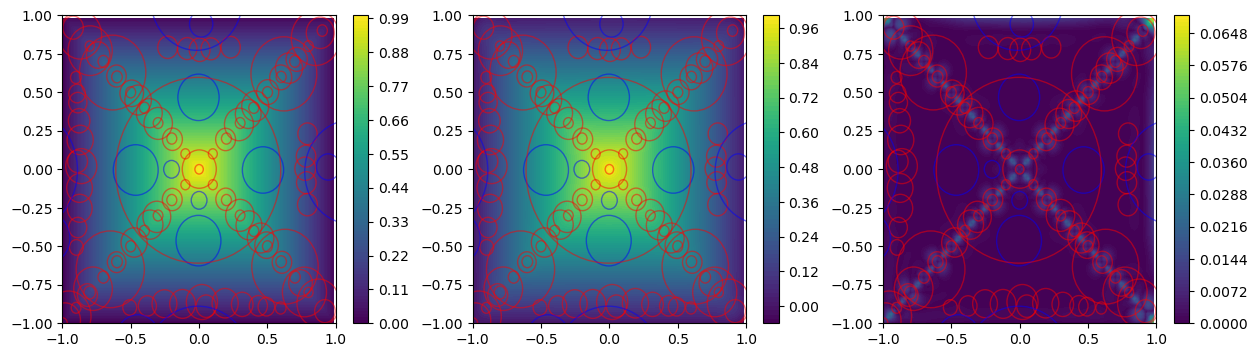

In [31]:
# 2D problem with a true function and predicted sources
resolution = 100
a_1 = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
a_2 = np.linspace(omega_space[1][0],omega_space[1][1],resolution, endpoint=False)
x, y = np.meshgrid(a_1,a_2)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = true_function(points).reshape((resolution,resolution))

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - points,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**variance_exponent)/(np.sqrt(2*np.pi)**d)
    return outer

pred_vals = u.duality_pairing(jax.vmap(plot_kernel)).reshape((resolution,resolution)) +c*np.ones((resolution, resolution))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
contour1 = ax1.contourf(x, y, vals, levels=100)
fig.colorbar(contour1, ax=ax1)
contour2 = ax2.contourf(x, y, pred_vals, levels=100)
fig.colorbar(contour2, ax=ax2)
contour3 = ax3.contourf(x, y, np.abs(pred_vals-vals), levels=100)
fig.colorbar(contour3, ax=ax3)
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i])
    ax1.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax2.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax3.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
ax1.set_xlim(omega_space[0][0],omega_space[0][1])
ax1.set_ylim(omega_space[1][0],omega_space[1][1])
ax2.set_xlim(omega_space[0][0],omega_space[0][1])
ax2.set_ylim(omega_space[1][0],omega_space[1][1])
ax3.set_xlim(omega_space[0][0],omega_space[0][1])
ax3.set_ylim(omega_space[1][0],omega_space[1][1])

logging.info(f"L2: {np.linalg.norm(pred_vals-vals)/len(vals)}, Linf: {np.max(np.abs(pred_vals-vals))}")

In [ ]:
# Higher-dimensional problem
resolution = 20
a_1 = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
a_2 = np.linspace(omega_space[1][0],omega_space[1][1],resolution, endpoint=False)
a_3 = np.linspace(omega_space[2][0],omega_space[2][1],resolution, endpoint=False)
a_4 = np.linspace(omega_space[3][0],omega_space[3][1],resolution, endpoint=False)
w, x, y, z = np.meshgrid(a_1,a_2,a_3,a_4)
points = np.array(list(zip(w.flatten(), x.flatten(), y.flatten(), z.flatten())))
vals = true_function(points)

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - points,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**variance_exponent)/(np.sqrt(2*np.pi)**d)
    return outer

pred_vals = u.duality_pairing(jax.vmap(plot_kernel)) +c*np.ones(points.shape[0])

err = np.abs(vals-pred_vals)
print(f"L2 error: {np.linalg.norm(err)}, Linf error: {np.max(err)}, average error: {np.mean(err)}")

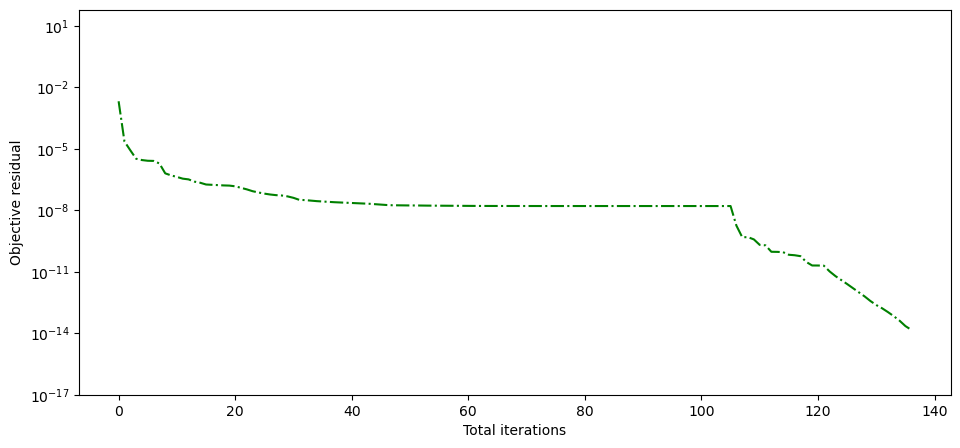

In [98]:
# Convergence in iterations with shaded inner loops
# intervals = []
# current_inner = False
# for ind, i in enumerate(inner_loop):
#     if i:
#         if not current_inner:
#             start = ind-0.5
#             current_inner = True
#     else:
#         if current_inner:
#             end = ind-0.5
#             intervals.append((start,end))
#             current_inner = False
# if inner_loop[-1]:
#     end = len(inner_loop)-0.5
#     intervals.append((start,end))

residuals = np.array(objective_values) - np.min(objective_values)
plt.figure(figsize=(11.25,5))
plt.semilogy(np.array(range(len(residuals)-1)), residuals[:-1], linestyle="-.", color="green");
# for interval in intervals:
#     plt.fill_between(interval, 0, 60, hatch="/", color="gray", alpha=0.2);
plt.ylim(1e-17, 60);
# plt.xlim(2500, 3000);
plt.ylabel("Objective residual");
plt.xlabel("Total iterations");
plt.show()

# PDEs

## Generate Data and Define Functions

In [ ]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [ ]:
sigma_space = np.array([0,1])
omega_space = np.array([[-1,1], [-1,1]])
Omega = np.vstack((sigma_space, omega_space))
d = omega_space.shape[0]
variance_exponent = 2.01
alpha = 1e-2
lambda_ = 1000
observation_resolution = 20

@jax.jit
def true_function(x: np.ndarray):
    return jnp.tanh(4*(0.3-jnp.linalg.norm(x-np.array([0.300000000000000001,0.3000000000000001]))))+jnp.tanh(12*(0.15-jnp.linalg.norm(x+np.array([0.300000000000001,0.3000000000000001]))))+2
grad_true_function = jax.jit(jax.grad(true_function))
hess_true_function = jax.jit(jax.hessian(true_function))
true_function = jax.vmap(true_function)
grad_true_function = jax.vmap(grad_true_function)
hess_true_function = jax.vmap(hess_true_function)

int_function = true_function
grad_int_function = grad_true_function
hess_int_function = hess_true_function
laplacian_int_function = lambda omega: jnp.trace(hess_int_function(omega),axis1=1, axis2=2)
bound_function = true_function

In [ ]:
observations_raw = (np.array(np.meshgrid(
                    *(
                        np.linspace(bound[0], bound[1], observation_resolution, endpoint=True)
                        for bound in omega_space
                    ))
            ).reshape(len(omega_space), -1).T)
int_observations = np.array([obs for obs in observations_raw if all(obs!=omega_space[0][0]) and all(obs!=omega_space[0][1])])
bound_observations = np.array([obs for obs in observations_raw if any(obs==omega_space[0][0]) or any(obs==omega_space[0][1])])

In [ ]:
int_target = int_function(int_observations)**3-laplacian_int_function(int_observations)
bound_target = np.sqrt(lambda_) * bound_function(bound_observations)
target = np.hstack((int_target, bound_target))
observations = np.vstack((int_observations, bound_observations))

constant_dim = len(target)
kernel_dim = len(target)+len(int_target)

In [ ]:
@jax.jit
def adjusted_sigmoid(x):
    return 2*jnp.exp(2*x)/(1+jnp.exp(2*x))-1

@jax.jit
def raw_kernel(omega: np.ndarray, x: np.ndarray):
    # Both inputs 1D
    sigma = omega[0]
    x_omega = omega[1:]
    variance_factor = adjusted_sigmoid(sigma**variance_exponent)
    inner = -(jnp.sum((x_omega - x)**2))/(2*sigma**2)
    outer = (jnp.exp(inner)*variance_factor)/(np.sqrt(2*np.pi)**d)
    return outer

hess_raw_kernel = jax.jit(jax.hessian(raw_kernel, argnums=1))
raw_kernel = jax.vmap(raw_kernel, (None, 0), 0)
hess_raw_kernel = jax.vmap(hess_raw_kernel, (None, 0), 0)

@jax.jit
def singleton_kernel(omega: np.ndarray):
    # function, laplacian
    return jnp.hstack([raw_kernel(omega, observations),jnp.trace(hess_raw_kernel(omega, int_observations),axis1=1, axis2=2)])

grad_kernel = jax.jit(jax.jacobian(singleton_kernel))
hess_kernel = jax.jit(jax.hessian(singleton_kernel))
_ = grad_kernel(np.ones(len(Omega)))
_ = hess_kernel(np.ones(len(Omega)))

kernel = jax.vmap(singleton_kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [ ]:
g = jax.jit(lambda w: alpha * jnp.linalg.norm(w, ord=1))
grad_g = jax.jit(jax.grad(g))
_ = grad_g(jnp.ones(1))

@jax.jit
def r(function_and_laplacian: np.ndarray) -> np.ndarray:
    u = function_and_laplacian[:len(target)] # shape (len(target),)
    laplacian = function_and_laplacian[len(target):] # shape (len(int_target),)
    to_return = jnp.hstack((u[:len(int_target)]**3 - laplacian, np.sqrt(lambda_) * u[len(int_target):]))
    return to_return

f = jax.jit(lambda y: 0.5 * jnp.sum((r(y)-target)**2)*4/len(target))
grad_f = jax.jit(jax.grad(f))
hess_f = jax.jit(jax.hessian(f))
_ = grad_f(jnp.ones(2*len(int_target)+len(bound_target)))
_ = hess_f(jnp.ones(2*len(int_target)+len(bound_target)))

j = lambda u, c: f(u.duality_pairing(kernel, kernel_dim)+np.hstack((c*np.ones(constant_dim), np.zeros(kernel_dim-constant_dim)))) + g(u.coefficients)

In [ ]:
# def p(u: Measure, c: float) -> Callable:
#     inner = -grad_f(u.duality_pairing(kernel, kernel_dim)+np.hstack((c*np.ones(constant_dim), np.zeros(kernel_dim-constant_dim))))
#     return lambda omega: kernel(omega) @ inner

# def grad_p(u: Measure, c: float) -> Callable:
#     inner = -grad_f(u.duality_pairing(kernel, kernel_dim)+np.hstack((c*np.ones(constant_dim), np.zeros(kernel_dim-constant_dim))))
#     return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

# def hess_p(u: Measure, c: float) -> Callable:
#     inner = -grad_f(u.duality_pairing(kernel, kernel_dim)+np.hstack((c*np.ones(constant_dim), np.zeros(kernel_dim-constant_dim))))
#     return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [ ]:
@jax.jit
def p_raw(parameters: np.ndarray, c: float, omega: np.ndarray):
    coefficients = parameters[:,0]
    support = parameters[:,1:]
    Ku = jnp.tensordot(kernel(support), coefficients, axes=([0], [0]))
    constant_term = jnp.hstack((c*jnp.ones(constant_dim), jnp.zeros(kernel_dim-constant_dim)))
    return singleton_kernel(omega) @ -grad_f(Ku+constant_term)

grad_p_raw = jax.jit(jax.grad(p_raw, argnums=2))
hess_p_raw = jax.jit(jax.hessian(p_raw, argnums=2))

p_raw = jax.jit(jax.vmap(p_raw, in_axes=(None, None, 0), out_axes=0))
grad_p_raw = jax.jit(jax.vmap(grad_p_raw, in_axes=(None, None, 0), out_axes=0))
hess_p_raw = jax.jit(jax.vmap(hess_p_raw, in_axes=(None, None, 0), out_axes=0))

p = lambda u, c: lambda omega: p_raw(u.to_matrix(len(Omega)), c, omega)
grad_p = lambda u, c: lambda omega: grad_p_raw(u.to_matrix(len(Omega)), c, omega)
hess_p = lambda u, c: lambda omega: hess_p_raw(u.to_matrix(len(Omega)), c, omega)

In [ ]:
# Parameterized versions of f and j
@jax.jit
def f_N(raw_input: np.ndarray) -> float:
    constant = raw_input[-1]
    input = raw_input[:-1].reshape(-1, d+2)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights+constant*jnp.hstack((jnp.ones(constant_dim), jnp.zeros(kernel_dim-constant_dim))))

@jax.jit
def j_N(raw_input: np.ndarray) -> float:
    input = raw_input[:-1].reshape(-1, d+2)
    weights = input[:,0]
    return f_N(raw_input) + g(weights)

grad_f_N = jax.jit(jax.grad(f_N))
hess_f_N = jax.jit(jax.hessian(f_N))
grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g,
           f=f,
           grad_f=grad_f,
           hess_f=hess_f,
           j=j,
           j_N=j_N,
           p=p,
           grad_p=grad_p,
           hess_p=hess_p,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=4,
           dual_variable_goodness=0.75,
           armijo_constant=1e-1,
           max_inner_loop=10,
           constant_dim=constant_dim,
           kernel_dim=kernel_dim,
           grad_f_N=grad_f_N,
           hess_f_N=hess_f_N,
           cg_lambda=1e-7
           )

In [ ]:
u = pickle.load(open("u.pkl", "rb")) # 1e-2
c = pickle.load(open("c.pkl", "rb"))

In [ ]:
u, c, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(inner_mode="trust_region_ssn",tol=5e-14, max_radius=0.001, mode="deterministic")

In [ ]:
# pickle.dump(u, open("u.pkl", "wb"))
# pickle.dump(c, open("c.pkl", "wb"))

In [ ]:
print(u)

In [ ]:
c

In [ ]:
full_parameters = np.hstack((u.to_matrix().flatten(), c))

In [ ]:
grd = exp.grad_j_N(full_parameters)
np.linalg.norm(grd)

In [ ]:
hss = exp.hess_j_N(full_parameters)
np.linalg.eigvals(hss)

## Plots

In [ ]:
parameters, u_ks, radii = exp.local_merging_update_radii(u, c)
radii

In [ ]:
# Projection of the dual variable on an axis
p_u = p(u, c)
resolution = 100
a_sigma = np.linspace(0,1,resolution, endpoint=False)
index = -26
points = np.array([u.support[index]]*resolution)
points[:,0]=a_sigma
vals = np.abs(p_u(points))

plt.plot(a_sigma, vals);
plt.plot([u.support[index][0]], np.abs(p_u(np.array([u.support[index]]))), "o", c="black", markersize=5);

In [ ]:
# 2D problem with a true function and predicted sources
resolution = 100
a_1 = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
a_2 = np.linspace(omega_space[1][0],omega_space[1][1],resolution, endpoint=False)
x, y = np.meshgrid(a_1,a_2)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = int_function(points).reshape((resolution,resolution))

@jax.jit
def plot_kernel(omega: np.ndarray):
    return raw_kernel(omega, points)
plot_kernel = jax.vmap(plot_kernel)

pred_vals = u.duality_pairing(plot_kernel).reshape((resolution,resolution)) +c*np.ones((resolution, resolution))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
contour1 = ax1.contourf(x, y, vals, levels=100)
fig.colorbar(contour1, ax=ax1)
contour2 = ax2.contourf(x, y, pred_vals, levels=100)
fig.colorbar(contour2, ax=ax2)
contour3 = ax3.contourf(x, y, np.abs(pred_vals-vals), levels=100)
fig.colorbar(contour3, ax=ax3)
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i])
    ax1.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax2.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax3.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
ax1.set_xlim(omega_space[0][0],omega_space[0][1])
ax1.set_ylim(omega_space[1][0],omega_space[1][1])
ax2.set_xlim(omega_space[0][0],omega_space[0][1])
ax2.set_ylim(omega_space[1][0],omega_space[1][1])
ax3.set_xlim(omega_space[0][0],omega_space[0][1])
ax3.set_ylim(omega_space[1][0],omega_space[1][1])

# Function Approximation (Sigmoid Shallow NN)

## Generate Data and Define Functions

In [ ]:
alpha = 1e-6

In [ ]:
# Function approximation
observation_size = 100
observation_space = np.array([[0,1], [0,1]])
Omega = np.array([[0,1], [0,1], [0,1]])
true_function = lambda x: np.sin(10*(x[0]**2+x[1]**2))

np.random.seed(49)
columns = []
for bounds in observation_space:
    columns.append(
        np.random.sample((observation_size, 1)) * (bounds[1] - bounds[0]) + bounds[0]
    )
observations = np.concatenate(columns, axis=1)
observations_bias = np.append(np.ones((observations.shape[0],1)),observations,axis=1)
target = np.array([true_function(x) for x in observations])

In [ ]:
activation = lambda omega: 1/(1+np.exp(omega)) # sigmoid
def kappa(x):
    # input is a 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation(linear_operation)
    return activated # shape (len(x), len(observations))

In [ ]:
def activation_grad(omega: np.ndarray) -> np.ndarray:
    sigmoid = activation(omega)
    return sigmoid * (1 - sigmoid)  # Derivative of the sigmoid function

def grad_kappa(x):
    # input is a 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation_grad(linear_operation) # shape=(len(x), len(observations))
    inner_derivative = np.repeat(np.expand_dims(observations_bias,axis=0),len(x),axis=0) # shape=(len(x), len(observations), Omega.shape[0])
    chain_rule = np.multiply(activated.reshape((len(x),len(observations),1)), inner_derivative)
    return chain_rule # shape (len(x), len(observations), Omega.shape[0])

In [ ]:
def activation_hess(omega: np.ndarray) -> np.ndarray:
    sigmoid = activation(omega)
    return sigmoid * (1 - sigmoid)*(1-2*sigmoid)  # Derivative of the sigmoid function

def hess_kappa(x):
    # Input is 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation_hess(linear_operation)
    inner_second_derivative_raw = np.array([np.outer(vect, vect) for vect in observations_bias]) # shape (len(observations),Omega.shape[0],Omega.shape[0])
    inner_second_derivative = np.repeat(np.expand_dims(inner_second_derivative_raw,axis=0),len(x),axis=0) # shape (len(x),len(observations),Omega.shape[0],Omega.shape[0])
    chain_rule = np.multiply(activated.reshape((len(x),len(observations),1,1)), inner_second_derivative)
    return chain_rule # shape (len(x), len(observations), Omega.shape[0], Omega.shape[0])

In [ ]:
g = lambda u: alpha * np.linalg.norm(u, ord=1)
f = lambda u: 0.5 * np.linalg.norm(u.duality_pairing(kappa) - target) ** 2

In [ ]:
def p_raw(u):
    Ku = u.duality_pairing(kappa)
    inner = Ku-target
    return lambda x: -kappa(x) @ inner

p = lambda u: p_raw(u)

In [ ]:
def grad_P_raw(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    return lambda x: np.sign(p_u(x)).reshape(-1,1)*np.tensordot(grad_kappa(x), inner, axes=([1,0]))

grad_P = lambda u: grad_P_raw(u)

In [ ]:
def grad_P_raw_sphere(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    def grad_P_x(x):
        unprojected = np.sign(p_u(x)).reshape(-1,1)*np.tensordot(grad_kappa(x), inner, axes=([1,0]))
        to_return = np.zeros(unprojected.shape)
        for i, (grad ,position) in enumerate(zip(unprojected, x)):
            # Project onto the ball
            projection = np.eye(len(position)) - np.outer(position, position)
            to_return[i] = projection@grad
        return to_return
    return grad_P_x

grad_P_sphere = lambda u: grad_P_raw_sphere(u)

In [ ]:
def hess_P_raw(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    return lambda x: np.sign(p_u(x)).reshape(-1,1,1)*np.tensordot(hess_kappa(x),inner,axes=([1,0]))

hess_P = lambda u: hess_P_raw(u)

In [ ]:
def hess_P_raw_sphere(u):
    p_u = p_raw(u)
    grad_u = grad_P(u)
    inner = target-u.duality_pairing(kappa)
    def hess_P_x(x):
        grads = grad_u(x)
        unprojected = np.sign(p_u(x)).reshape(-1,1,1)*np.tensordot(hess_kappa(x),inner,axes=([1,0]))
        to_return = np.zeros(unprojected.shape)
        for i, (grad, hess, position) in enumerate(zip(grads, unprojected, x)):
            # P_x(hess-position.T*grad*I)
            projection = np.eye(len(position)) - np.outer(position, position)
            identity_factor = position@grad
            to_return[i] = projection@(hess-identity_factor*np.eye(len(position)))@projection
        return to_return
    return hess_P_x

hess_P_sphere = lambda u: hess_P_raw_sphere(u)

In [ ]:
def grad_j(positions, coefs):
    K_matrix = kappa(positions)
    grad_F = (K_matrix.T@coefs).flatten() - target
    nabla_x = coefs.reshape(-1,1)*np.tensordot(grad_kappa(positions), grad_F, axes=([1,0]))
    nabla_u = np.dot(K_matrix, grad_F) + alpha * np.sign(coefs)
    return np.append(nabla_x.flatten(), nabla_u, axis=0).flatten()

In [ ]:
def grad_j_sphere(positions, coefs):
    K_matrix = kappa(positions)
    grad_F = (K_matrix.T@coefs).flatten() - target
    nabla_x = coefs.reshape(-1,1)*np.tensordot(grad_kappa(positions), grad_F, axes=([1,0]))
    for i, (grad ,position) in enumerate(zip(nabla_x, positions)):
        # Project onto the ball
        nabla_x[i] = (np.eye(len(position))-np.outer(position, position))@grad
    nabla_u = np.dot(K_matrix, grad_F) + alpha * np.sign(coefs)
    return np.append(nabla_x.flatten(), nabla_u, axis=0).flatten()

In [ ]:
def hess_j(positions, coefs):
    kappa_values = kappa(positions)
    grad_kappa_values = grad_kappa(positions)
    hess_kappa_values = hess_kappa(positions)
    matrix_dimension = len(positions)*Omega.shape[0] + len(coefs)
    hesse_matrix = np.zeros((matrix_dimension, matrix_dimension))
    step = Omega.shape[0]
    coefs_delay = step*len(positions)
    inner = (kappa_values.T@coefs).flatten() - target
    for i in range(len(positions)):
        # nabla_{x_i,x_j}
        for j in range(len(positions)):
            if j<i:
                continue
            block = coefs[i]*coefs[j]*np.matmul(grad_kappa_values[i].T, grad_kappa_values[j])
            if i==j:
                block += coefs[i]*np.tensordot(hess_kappa_values[i],inner,axes=([0,0]))
            hesse_matrix[i*step:(i+1)*step, j*step:(j+1)*step] = block
            hesse_matrix[j*step:(j+1)*step, i*step:(i+1)*step] = block.T
        # nabla_{x_i,u_j}
        for j in range(len(coefs)):
            block = coefs[i]*np.matmul(grad_kappa_values[i].T, kappa_values[j])
            if i == j:
                block += np.matmul(grad_kappa_values[i].T, inner)
            hesse_matrix[i*step:(i+1)*step, coefs_delay+j] = block
            hesse_matrix[coefs_delay+j, i*step:(i+1)*step] = block.T
    for i in range(len(coefs)):
        # nabla_{u_i,u_j}
        for j in range(len(coefs)):
            if j<i:
                continue
            block = np.dot(kappa_values[i], kappa_values[j])
            hesse_matrix[coefs_delay+i,coefs_delay+j] = block
            hesse_matrix[coefs_delay+j,coefs_delay+i] = block
    return hesse_matrix

In [ ]:
def hess_j_sphere(positions, coefs):
    hessian = hess_j(positions, coefs)
    gradient = grad_j(positions, coefs)
    projection = np.eye(hessian.shape[0])
    inner_matrix = np.eye(hessian.shape[0])
    for i, position in enumerate(positions):
        projection_part = np.eye(len(position))-np.outer(position, position)
        inner_matrix_part = (position@gradient[i*len(position):(i+1)*len(position)])*np.eye(len(position))
        projection[i*len(position):(i+1)*len(position), i*len(position):(i+1)*len(position)] = projection_part
        inner_matrix[i*len(position):(i+1)*len(position), i*len(position):(i+1)*len(position)] = inner_matrix_part
    hesse_system = projection@(hessian-inner_matrix)@projection
    return hesse_system

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kappa=kappa, 
           g=g, 
           f=f,
           p=p,
           grad_P=grad_P_sphere,
           hess_P=hess_P_sphere,
           grad_j=grad_j_sphere,
           hess_j=hess_j_sphere,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=100,
           dual_variable_goodness=0.3,
           projection="sphere"
           )

In [ ]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=0.1)

## Plots

In [ ]:
a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
X = np.array(list(zip(B.flatten(), D.flatten())))
true_vals = np.array([true_function(x) for x in X]).reshape((100,100))

plt.contourf(B, D, true_vals, levels=100);
plt.colorbar();
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);

In [ ]:
def predicted(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    x_bias = np.append(np.ones((x.shape[0],1)),x,axis=1)
    activated = activation(x_bias@u.support.T) # shape (len(x), len(observations))
    output = np.dot(activated, u.coefficients) # shape (len(x),)
    return output

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
pred_vals = predicted(x).reshape((100,100))
error = true_vals - pred_vals

print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(x)):.3E}, Linf error: {np.max(np.abs(error)):.3E}")

plt.contourf(B, D, np.abs(error), levels=100);
plt.colorbar();
for i, x in enumerate(observations):
    plt.plot([x[0]], [x[1]], "P", c="r", markersize=4);